In [1]:
import matplotlib.pyplot as plt
import seaborn as sns
import os
from plot_utils import plot_results


In [2]:
action_spaces = [
    "joint-velocity",
    # "joint-torque",
    "cartesian_increment-position",
    "joint_increment-position",
]
prefix = "PandaPickCubeCartesianModified"
postfix="_prop-seed"
logs_dir = "../logs"
# resolve logsdir

logs_dir = os.path.abspath(logs_dir)

In [3]:
## List path of all event files in directory

# recursively list all event files under logs_dir
event_files = []
for root, _, files in os.walk(logs_dir):
    for f in files:
        if f.startswith("events.out.tfevents"):
            event_files.append(os.path.join(root, f))
event_files, len(event_files);

In [4]:
# group the runs
run_groups = {}

for action_space in action_spaces:
    run_groups[action_space] = []
    for ef in event_files:
        parent = os.path.basename(os.path.dirname(ef))
        if action_space in ef:
            run_groups[action_space].append(ef)

# deduplicate and sort each group
for k in run_groups:
    run_groups[k] = sorted(set(run_groups[k]))

# show counts per group
{k: len(v) for k, v in run_groups.items()}

{'joint-velocity': 10,
 'cartesian_increment-position': 10,
 'joint_increment-position': 10}

In [5]:
## Let's first plot results for one action space

tb_tags_list = [
    "episode/success",
    "episode/sum_reward",
    "episode/floor_collision",
    "episode/jerk"
]

In [6]:
axis_tag_names = {
    "episode/success": "Success Rate",
    "episode/sum_reward": "Episodic Return",
    "episode/floor_collision": "Floor Collisions",
    "episode/jerk": "Jerk",
}

In [7]:
legend_names = {
    "joint-velocity": r"$v$",
    "joint-torque": r"$\tau$",
    "cartesian_increment-position": r"$\delta x$",
    "joint_increment-position": r"$\delta q$",
}

generating plot


0it [00:00, ?it/s]

1it [00:11, 11.42s/it]

Processing tag 'episode/success' with 977 rows
PandaPickCubeCartesianModified-joint-velocity-_prop-seed-0    0.985
PandaPickCubeCartesianModified-joint-velocity-_prop-seed-1    0.985
PandaPickCubeCartesianModified-joint-velocity-_prop-seed-2    0.990
PandaPickCubeCartesianModified-joint-velocity-_prop-seed-3    0.965
PandaPickCubeCartesianModified-joint-velocity-_prop-seed-4    1.000
PandaPickCubeCartesianModified-joint-velocity-_prop-seed-5    0.980
PandaPickCubeCartesianModified-joint-velocity-_prop-seed-6    0.975
PandaPickCubeCartesianModified-joint-velocity-_prop-seed-7    0.980
PandaPickCubeCartesianModified-joint-velocity-_prop-seed-8    0.985
PandaPickCubeCartesianModified-joint-velocity-_prop-seed-9    0.985
dtype: float64
Processing tag 'episode/sum_reward' with 977 rows
PandaPickCubeCartesianModified-joint-velocity-_prop-seed-0    11.272346
PandaPickCubeCartesianModified-joint-velocity-_prop-seed-1    11.091889
PandaPickCubeCartesianModified-joint-velocity-_prop-seed-2    10

2it [00:22, 11.48s/it]

Processing tag 'episode/success' with 980 rows
PandaPickCubeCartesianModified-cartesian_increment-position-_prop-seed-0    0.992
PandaPickCubeCartesianModified-cartesian_increment-position-_prop-seed-1    0.998
PandaPickCubeCartesianModified-cartesian_increment-position-_prop-seed-2    0.996
PandaPickCubeCartesianModified-cartesian_increment-position-_prop-seed-3    0.994
PandaPickCubeCartesianModified-cartesian_increment-position-_prop-seed-4    0.990
PandaPickCubeCartesianModified-cartesian_increment-position-_prop-seed-5    0.998
PandaPickCubeCartesianModified-cartesian_increment-position-_prop-seed-6    0.990
PandaPickCubeCartesianModified-cartesian_increment-position-_prop-seed-7    0.994
PandaPickCubeCartesianModified-cartesian_increment-position-_prop-seed-8    0.994
PandaPickCubeCartesianModified-cartesian_increment-position-_prop-seed-9    0.996
dtype: float64
Processing tag 'episode/sum_reward' with 980 rows
PandaPickCubeCartesianModified-cartesian_increment-position-_prop-se

3it [00:34, 11.48s/it]

Processing tag 'episode/success' with 980 rows
PandaPickCubeCartesianModified-joint_increment-position-_prop-seed-0    0.986
PandaPickCubeCartesianModified-joint_increment-position-_prop-seed-1    0.980
PandaPickCubeCartesianModified-joint_increment-position-_prop-seed-2    0.992
PandaPickCubeCartesianModified-joint_increment-position-_prop-seed-3    0.984
PandaPickCubeCartesianModified-joint_increment-position-_prop-seed-4    0.996
PandaPickCubeCartesianModified-joint_increment-position-_prop-seed-5    0.990
PandaPickCubeCartesianModified-joint_increment-position-_prop-seed-6    0.988
PandaPickCubeCartesianModified-joint_increment-position-_prop-seed-7    0.988
PandaPickCubeCartesianModified-joint_increment-position-_prop-seed-8    0.988
PandaPickCubeCartesianModified-joint_increment-position-_prop-seed-9    0.990
dtype: float64
Processing tag 'episode/sum_reward' with 980 rows
PandaPickCubeCartesianModified-joint_increment-position-_prop-seed-0    11.416339
PandaPickCubeCartesianModi

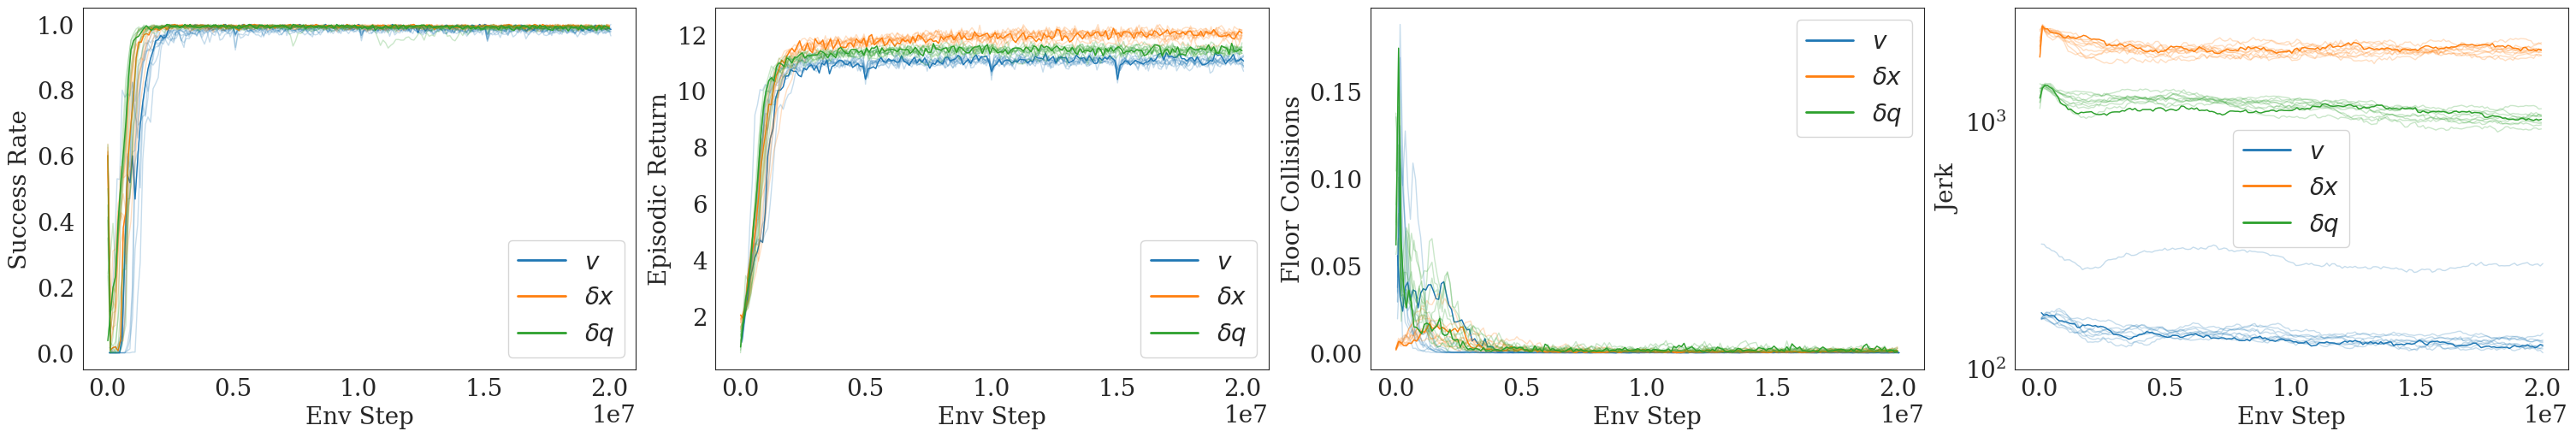

In [8]:
plot_results(run_groups, legend_names)